# TP 1 : Comparaison de Stratégies de Chunking - CORRECTION

## Solution complète du TP

In [1]:
!pip install langchain langchain-text-splitters langchain-experimental
!pip install sentence-transformers chromadb
!pip install matplotlib seaborn pandas numpy


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached sentence_transformers-5.5.1-py3-none-any.whl.metadata (18 kB)
  Using cached chromadb-1.5.9-cp39-abi3-win_amd64.whl.metadata (5.1 kB)
Using cached sentence_transformers-5.5.1-py3-none-any.whl (588 kB)
Using cached chromadb-1.5.9-cp39-abi3-win_amd64.whl (23.5 MB)



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-3.0.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached pandas-3.0.3-cp311-cp311-win_amd64.whl (9.9 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
 
warnings.filterwarnings("ignore")
 
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
    MarkdownTextSplitter,
) 

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
 
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

In [3]:
# Document long : Guide complet Machine Learning
ml_document = """
# Machine Learning : Guide Complet pour Debutants et Experts

## Introduction au Machine Learning

Le Machine Learning (apprentissage automatique) est une branche de l'intelligence artificielle qui permet aux ordinateurs d'apprendre et de s'ameliorer a partir de l'experience sans etre explicitement programmes. Contrairement a la programmation traditionnelle ou un developpeur ecrit des regles explicites, le machine learning permet aux systemes de decouvrir automatiquement des patterns dans les donnees.

Cette discipline a connu une explosion spectaculaire ces dernieres annees grace a trois facteurs cles : l'augmentation massive de la puissance de calcul, la disponibilite de grandes quantites de donnees, et les avancees algorithmiques. Aujourd'hui, le machine learning alimente une multitude d'applications que nous utilisons quotidiennement : recommandations Netflix, reconnaissance vocale Siri, detection de spam, voitures autonomes, diagnostic medical, et bien plus encore.

## Types d'Apprentissage

### 1. Apprentissage Supervise

L'apprentissage supervise est le paradigme le plus courant en machine learning. Dans cette approche, le modele apprend a partir d'un dataset labelise, c'est-a-dire un ensemble de donnees ou chaque exemple d'entree est associe a sa sortie correcte (label). Le modele apprend a mapper les entrees vers les sorties en minimisant l'erreur de prediction.

Les taches d'apprentissage supervise se divisent en deux categories principales :

**Classification** : Predire une categorie discrete. Par exemple, classifier un email comme spam ou non-spam, diagnostiquer une maladie, reconnaitre des chiffres manuscrits (MNIST), ou classifier des images (chien vs chat). Les algorithmes populaires incluent la regression logistique, les arbres de decision, Random Forest, SVM (Support Vector Machines), et les reseaux de neurones.

**Regression** : Predire une valeur continue. Par exemple, predire le prix d'une maison en fonction de ses caracteristiques (superficie, nombre de chambres, localisation), predire les ventes futures d'un produit, ou estimer l'age d'une personne a partir d'une photo. Les algorithmes courants sont la regression lineaire, la regression polynomiale, et les reseaux de neurones de regression.

### 2. Apprentissage Non Supervise

L'apprentissage non supervise travaille avec des donnees non labelisees. L'objectif est de decouvrir des structures cachees, des patterns ou des groupements naturels dans les donnees sans aucune indication prealable sur ce qu'il faut chercher.

Les principales taches non supervisees sont :

**Clustering** : Regrouper des donnees similaires ensemble. K-means est l'algorithme le plus connu : il partitionne les donnees en K clusters en minimisant la variance intra-cluster. DBSCAN est une alternative qui peut detecter des clusters de formes arbitraires et identifier les outliers. Les applications incluent la segmentation de clients, la compression d'images, et l'organisation de documents.

**Reduction de dimensionnalite** : Reduire le nombre de features tout en preservant l'information importante. PCA (Principal Component Analysis) projette les donnees sur les axes de variance maximale. t-SNE et UMAP sont utilises pour visualiser des donnees haute-dimension en 2D ou 3D. Ces techniques sont cruciales pour la visualisation, l'acceleration des algorithmes, et la reduction du bruit.

**Detection d'anomalies** : Identifier des observations qui devient significativement de la norme. Applications en cybersecurite (detection d'intrusions), finance (detection de fraude), et maintenance predictive (detection de defaillances).

### 3. Apprentissage par Renforcement

L'apprentissage par renforcement (Reinforcement Learning) est un paradigme ou un agent apprend a prendre des decisions en interagissant avec un environnement. L'agent reoit des recompenses (positives ou negatives) en fonction de ses actions, et son objectif est de maximiser la recompense cumulee sur le long terme.

Les composants cles sont : l'agent (celui qui apprend), l'environnement (le monde dans lequel l'agent evolue), l'etat (situation actuelle), l'action (choix de l'agent), et la recompense (feedback numerique).

Les applications incluent : AlphaGo (jeu de Go), robotique (manipulation d'objets), voitures autonomes, optimisation de ressources (data centers), et trading algorithmique.

## Reseaux de Neurones et Deep Learning

### Architecture d'un Reseau de Neurones

Un reseau de neurones artificiel est inspire du cerveau humain. Il est compose de couches de neurones interconnectes :

**Couche d'entree** : Reoit les features brutes (pixels d'image, mots d'un texte, valeurs numeriques).

**Couches cachees** : Transforment progressivement les entrees en representations de plus en plus abstraites. Chaque neurone calcule une somme ponderee de ses entrees, ajoute un biais, puis applique une fonction d'activation non-lineaire.

**Couche de sortie** : Produit la prediction finale (probabilites pour classification, valeur pour regression).

Le deep learning designe les reseaux avec plusieurs couches cachees (parfois des centaines). Plus le reseau est profond, plus il peut apprendre des representations complexes et hierarchiques.

### Fonctions d'Activation

Les fonctions d'activation introduisent la non-linearite, permettant aux reseaux d'apprendre des relations complexes :

**ReLU** (Rectified Linear Unit) : f(x) = max(0, x). Simple et efficace, c'est la plus utilisee dans les couches cachees. Evite le probleme de gradient evanescent mais peut souffrir de "dying ReLU" (neurones morts).

**Sigmoid** : f(x) = 1 / (1 + e^-x). Compresse les valeurs entre 0 et 1. Utile pour la sortie de classification binaire mais souffre de gradient evanescent.

**Tanh** : f(x) = (e^x - e^-x) / (e^x + e^-x). Centre les valeurs entre -1 et 1. Meilleure que sigmoid pour les couches cachees mais toujours sujet au gradient evanescent.

**Softmax** : Convertit un vecteur en distribution de probabilites. Utilisee en sortie pour classification multi-classes.

### Backpropagation et Gradient Descent

L'entrainement d'un reseau de neurones repose sur deux algorithmes fondamentaux :

**Backpropagation** : Calcule le gradient de la fonction de cout par rapport a chaque poids du reseau en propageant l'erreur depuis la sortie vers l'entree, en utilisant la regle de derivation en chaine.

**Gradient Descent** : Utilise ces gradients pour mettre a jour les poids dans la direction qui reduit l'erreur. Plusieurs variantes existent :

- **Batch Gradient Descent** : Utilise tout le dataset a chaque iteration. Precis mais lent et gourmand en memoire.
- **Stochastic Gradient Descent (SGD)** : Utilise un seul exemple a la fois. Rapide mais bruyant.
- **Mini-batch Gradient Descent** : Compromis utilisant un petit batch (32, 64, 128 exemples). C'est le standard en pratique.

### Optimiseurs Avances

Des optimiseurs plus sophistiques ameliorent la convergence :

**Adam** (Adaptive Moment Estimation) : Combine momentum et learning rate adaptatif. C'est le choix par defaut pour la plupart des cas. Hyperparametres typiques : learning_rate=0.001, beta1=0.9, beta2=0.999.

**RMSprop** : Adapte le learning rate pour chaque parametre. Bon pour les RNN.

**AdaGrad** : Reduit le learning rate pour les features frequentes. Utile pour donnees sparse.

**Momentum** : Accelere la descente en accumulant une velocite dans les directions consistantes.

## Regularisation et Prevention de l'Overfitting

L'overfitting (sur-apprentissage) survient quand le modele memorise le training set au lieu de generaliser. Le modele performe parfaitement sur les donnees d'entrainement mais echoue sur les nouvelles donnees.

### Techniques de Regularisation

**L1 Regularization (Lasso)** : Ajoute la somme des valeurs absolues des poids a la fonction de cout. Favorise la sparsity (beaucoup de poids a zero), effectuant ainsi une selection de features.

**L2 Regularization (Ridge)** : Ajoute la somme des carres des poids. Penalise les grands poids sans forcer a zero. C'est la plus courante.

**Elastic Net** : Combine L1 et L2 pour obtenir le meilleur des deux mondes.

**Dropout** : Desactive aleatoirement une proportion de neurones (typiquement 20-50%) a chaque iteration d'entrainement. Force le reseau a apprendre des representations redondantes et robustes. Invente par Hinton et al., c'est devenu essentiel pour les grands reseaux.

**Early Stopping** : Surveille la performance sur un validation set pendant l'entrainement. Arrete quand la validation loss commence a augmenter, meme si la training loss continue de baisser.

**Data Augmentation** : Augmente artificiellement la taille du dataset en appliquant des transformations : rotations, translations, flips pour images ; ajout de bruit pour audio ; synonymes pour texte. Reduit l'overfitting en exposant le modele a plus de variabilite.

**Batch Normalization** : Normalise les activations de chaque couche pendant l'entrainement. Stabilise et accelere l'apprentissage, reduit la dependance a l'initialisation, et a un leger effet regularisant.

## Convolutional Neural Networks (CNN)

Les CNN sont specialises pour les donnees avec structure spatiale, notamment les images.

### Architecture CNN

**Couches Convolutives** : Appliquent des filtres (kernels) qui balayent l'image pour detecter des features locales. Les premieres couches detectent des edges et textures simples. Les couches profondes detectent des patterns complexes (yeux, roues, visages).

**Pooling Layers** : Reduisent la dimensionnalite spatiale. Max pooling garde la valeur maximale dans chaque region, rendant la representation plus robuste aux petites translations.

**Fully Connected Layers** : A la fin du reseau, prennent les features extraites et produisent la classification finale.

**Architectures celebres** :
- **LeNet-5** (1998) : Pionnier pour MNIST
- **AlexNet** (2012) : Victoire a ImageNet, debut du deep learning boom
- **VGG** (2014) : Tres profond, couches 3x3 empilees
- **ResNet** (2015) : Skip connections pour reseaux tres profonds (152 couches)
- **EfficientNet** (2019) : Optimise precision/efficacite avec compound scaling

## Recurrent Neural Networks (RNN)

Les RNN sont concus pour les donnees sequentielles : texte, series temporelles, audio, video.

### Principe des RNN

Un RNN maintient un etat cache qui est mis a jour a chaque pas de temps : h_t = f(h_{t-1}, x_t). Cette memoire interne permet de capturer des dependances temporelles.

**Probleme** : Les RNN vanilles souffrent du probleme de gradient evanescent/explosif sur les sequences longues.

### LSTM (Long Short-Term Memory)

Les LSTM resolvent ce probleme avec une architecture complexe incluant :
- **Forget gate** : Decide quoi oublier de la memoire
- **Input gate** : Decide quoi ajouter
- **Output gate** : Decide quoi sortir
- **Cell state** : Autoroute de l'information a travers le temps

### GRU (Gated Recurrent Unit)

Version simplifiee du LSTM avec seulement deux gates (reset et update). Moins de parametres, entrainement plus rapide, performances souvent comparables.

**Applications RNN/LSTM** : Traduction automatique, generation de texte, reconnaissance vocale, sentiment analysis, prediction de series temporelles.

## Transformers et Attention

Les Transformers ont revolutionne le NLP et au-dela depuis 2017.

### Mecanisme d'Attention

L'attention permet au modele de se concentrer sur les parties pertinentes de l'entree lors du traitement de chaque element de sortie.

**Self-Attention** : Chaque mot de la phrase "attends" a tous les autres mots pour comprendre le contexte. Calcule des scores d'attention qui ponderent l'importance de chaque mot pour chaque autre mot.

**Multi-Head Attention** : Plusieurs mecanismes d'attention en parallele, permettant de capturer differents types de relations (syntaxiques, semantiques, etc.).

### Architecture Transformer

**Encoder** : Stack de couches (self-attention + feed-forward) qui encodent l'entree en representations riches.

**Decoder** : Stack similaire avec en plus une attention croisee vers l'encodeur, pour la generation.

**Avantages** :
- Parallelisation complete (vs sequentiel pour RNN)
- Capture des dependances a longue distance
- Performance state-of-the-art

### Modeles Pre-entraines

**BERT** (Bidirectional Encoder Representations from Transformers) : Pre-entraine sur d'enormes corpus avec masked language modeling. Excellent pour comprendre le contexte.

**GPT** (Generative Pre-trained Transformer) : Pre-entraine de maniere autoregressive pour predire le mot suivant. Excellent pour la generation.

**T5** (Text-to-Text Transfer Transformer) : Formule toutes les taches NLP comme des problemes texte-vers-texte.

## Transfer Learning et Fine-tuning

Le transfer learning reutilise des modeles pre-entraines sur de grandes taches pour les adapter a des taches specifiques avec peu de donnees.

### Approches

**Feature Extraction** : Geler les poids du modele pre-entraine et entrainer seulement une nouvelle couche de sortie.

**Fine-tuning** : Degeler les couches et les re-entrainer sur la nouvelle tache avec un learning rate tres faible.

**Avantages** :
- Necessite beaucoup moins de donnees
- Temps d'entrainement reduit
- Meilleure performance que partir de zero
- Accessible meme avec ressources limitees

### Strategies

Pour vision : Utiliser ResNet/EfficientNet pre-entraine sur ImageNet.
Pour NLP : Utiliser BERT/GPT pre-entraine sur Wikipedia/Books.

**Recommandations** :
- Dataset petit (<1000 exemples) : Feature extraction uniquement
- Dataset moyen (1000-10000) : Fine-tune les dernieres couches
- Dataset large (>10000) : Fine-tune toutes les couches

## Evaluation et Metriques

### Classification

**Accuracy** : Proportion de predictions correctes. Simple mais trompeuse si classes desequilibrees.

**Precision** : TP / (TP + FP). Parmi ce que j'ai predit positif, combien sont vraiment positifs ? Important quand les faux positifs coutent cher.

**Recall** : TP / (TP + FN). Parmi tous les positifs reels, combien j'en ai detectes ? Important quand les faux negatifs coutent cher.

**F1-Score** : Moyenne harmonique de precision et recall. Bon equilibre.

**AUC-ROC** : Aire sous la courbe ROC. Mesure la capacite a distinguer les classes independamment du seuil.

### Regression

**MAE** (Mean Absolute Error) : Moyenne des erreurs absolues. Robuste aux outliers.

**MSE** (Mean Squared Error) : Moyenne des erreurs au carre. Penalise fortement les grandes erreurs.

**RMSE** : Racine du MSE. Meme unite que la cible.

**R²** : Coefficient de determination. Proportion de variance expliquee (1 = parfait, 0 = nul).

## Conclusion

Le machine learning est un domaine vaste et en constante evolution. Cette introduction couvre les fondamentaux, mais chaque sujet meriterait un cours complet. Les cles du succes sont : comprendre les principes sous-jacents, pratiquer sur des projets reels, experimenter avec differentes architectures et hyperparametres, et rester a jour avec les dernieres recherches.

Les prochaines etapes d'apprentissage pourraient inclure : GANs (Generative Adversarial Networks), autoencoders, graph neural networks, few-shot learning, meta-learning, et les derniers developpements en large language models (GPT-4, PaLM, etc.).
"""

print(f"Longueur du document : {len(ml_document)} caracteres")
print(f"Nombre de mots : {len(ml_document.split())} mots")
print(f"Pages estimees (500 mots/page) : {len(ml_document.split()) / 500:.1f} pages")

Longueur du document : 15260 caracteres
Nombre de mots : 2145 mots
Pages estimees (500 mots/page) : 4.3 pages


## SOLUTION 1 : RecursiveCharacterTextSplitter

In [4]:
# RecursiveCharacterTextSplitter avec parametres optimaux
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", ", ", " ", ""]
)

recursive_chunks = recursive_splitter.split_text(ml_document)

print(f"RecursiveCharacterTextSplitter :")
print(f"  Nombre de chunks : {len(recursive_chunks)}")
print(f"  Exemple de chunk 1 (extrait) :\n{recursive_chunks[0][:200]}...\n")

RecursiveCharacterTextSplitter :
  Nombre de chunks : 39
  Exemple de chunk 1 (extrait) :
# Machine Learning : Guide Complet pour Debutants et Experts

## Introduction au Machine Learning...



## SOLUTION 2 : MarkdownTextSplitter

In [5]:
# MarkdownTextSplitter pour respecter la structure
markdown_splitter = MarkdownTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

markdown_chunks = markdown_splitter.split_text(ml_document)

print(f"MarkdownTextSplitter :")
print(f"  Nombre de chunks : {len(markdown_chunks)}")
print(f"  Exemple de chunk 1 (extrait) :\n{markdown_chunks[0][:200]}...\n")

MarkdownTextSplitter :
  Nombre de chunks : 39
  Exemple de chunk 1 (extrait) :
# Machine Learning : Guide Complet pour Debutants et Experts

## Introduction au Machine Learning...



## SOLUTION 3 : Analyse des Statistiques

In [ ]:
def analyze_chunks(chunks, name):
    # Gerer les chunks de type Document
    if isinstance(chunks[0], Document):
        sizes = [len(c.page_content) for c in chunks]
    else:
        sizes = [len(c) for c in chunks]
    
    return {
        "Strategie": name,
        "Nombre de chunks": len(chunks),
        "Taille moyenne": int(np.mean(sizes)),
        "Taille mediane": int(np.median(sizes)),
        "Taille min": min(sizes),
        "Taille max": max(sizes),
        "Ecart-type": int(np.std(sizes))
    }

# Analyser les deux strategies
stats_recursive = analyze_chunks(recursive_chunks, "Recursive")
stats_markdown = analyze_chunks(markdown_chunks, "Markdown")

# Afficher les resultats
df_stats = pd.DataFrame([stats_recursive, stats_markdown])
print(df_stats.to_string(index=False))


=== STATISTIQUES DES STRATEGIES ===

Strategie  Nombre de chunks  Taille moyenne  Taille mediane  Taille min  Taille max  Ecart-type
Recursive                39             399             415          97         496          82
 Markdown                39             399             415          97         496          82


## SOLUTION 4 : Visualisation des Distributions

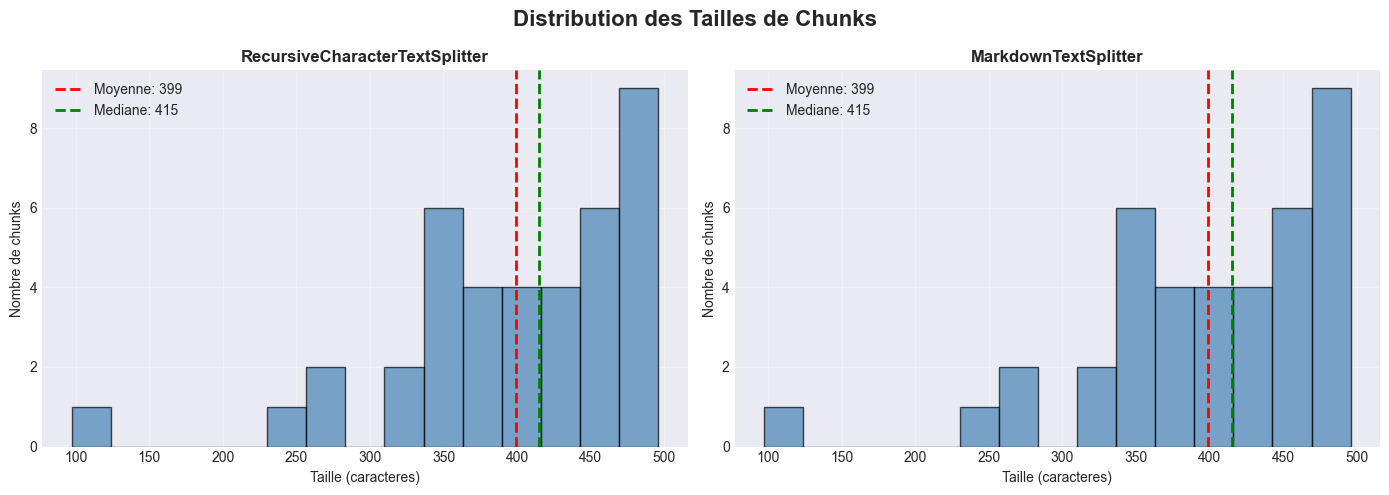

In [7]:
# Visualiser la distribution des tailles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des Tailles de Chunks', fontsize=16, fontweight='bold')

strategies = [
    (recursive_chunks, "RecursiveCharacterTextSplitter", axes[0]),
    (markdown_chunks, "MarkdownTextSplitter", axes[1])
]

for chunks, title, ax in strategies:
    sizes = [len(c) for c in chunks]
    
    ax.hist(sizes, bins=15, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(np.mean(sizes), color='red', linestyle='--', linewidth=2, 
               label=f'Moyenne: {int(np.mean(sizes))}')
    ax.axvline(np.median(sizes), color='green', linestyle='--', linewidth=2, 
               label=f'Mediane: {int(np.median(sizes))}')
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Taille (caracteres)')
    ax.set_ylabel('Nombre de chunks')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## SOLUTION 5 : Indexation dans ChromaDB

In [ ]:
import chromadb
from chromadb.utils import embedding_functions

# Creer un client ChromaDB
client = chromadb.Client()

# Fonction d'embedding
embedding_function = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# Fonction pour indexer une strategie
def index_chunks(chunks, collection_name):
    # Supprimer la collection si elle existe
    try:
        client.delete_collection(name=collection_name)
    except:
        pass
    
    # Creer la collection
    collection = client.create_collection(
        name=collection_name,
        embedding_function=embedding_function
    )
    
    # Preparer les documents
    if isinstance(chunks[0], Document):
        documents = [c.page_content for c in chunks]
    else:
        documents = chunks
    
    ids = [f"chunk_{i}" for i in range(len(documents))]
    
    # Ajouter a la collection
    collection.add(
        documents=documents,
        ids=ids
    )
    
    print(f"Collection '{collection_name}' creee avec {len(documents)} chunks")
    return collection

# Indexer les 2 strategies
collection_recursive = index_chunks(recursive_chunks, "ml_recursive")
collection_markdown = index_chunks(markdown_chunks, "ml_markdown")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3959.43it/s]


Collection 'ml_recursive' creee avec 39 chunks
Collection 'ml_markdown' creee avec 39 chunks


## SOLUTION 6 : Test de Qualite de Recherche

In [ ]:
# Questions de test
test_queries = [
    "Qu'est-ce que le transfer learning en machine learning ?",
    "Comment fonctionne l'attention dans les Transformers ?",
    "Quelles sont les differences entre CNN et RNN ?",
    "Comment prevenir l'overfitting ?",
    "Qu'est-ce que le fine-tuning d'un modele pre-entraine ?"
]

def test_search_quality(collection, collection_name, queries):
    print(f"\n=== RESULTATS POUR {collection_name.upper()} ===\n")
    
    results = []
    
    for i, query in enumerate(queries, 1):
        print(f"\nQuestion {i}: {query}")
        
        # Rechercher les top-3 resultats
        search_results = collection.query(
            query_texts=[query],
            n_results=3
        )
        
        # Afficher les resultats
        for j, (doc, distance) in enumerate(zip(search_results['documents'][0], 
                                                  search_results['distances'][0]), 1):
            print(f"\nResultat {j} (distance: {distance:.4f}):")
            print(doc[:200] + "...")
        
        # Stocker pour comparaison
        results.append({
            "query": query,
            "top1_distance": search_results['distances'][0][0],
            "top1_preview": search_results['documents'][0][0][:100]
        })
    
    return results

# Tester les 2 strategies
results_recursive = test_search_quality(collection_recursive, "Recursive", test_queries)
results_markdown = test_search_quality(collection_markdown, "Markdown", test_queries)


=== RESULTATS POUR RECURSIVE ===


Question 1: Qu'est-ce que le transfer learning en machine learning ?
--------------------------------------------------------------------------------

Resultat 1 (distance: 0.2984):
## Conclusion

Le machine learning est un domaine vaste et en constante evolution. Cette introduction couvre les fondamentaux, mais chaque sujet meriterait un cours complet. Les cles du succes sont : ...

Resultat 2 (distance: 0.3968):
## Transfer Learning et Fine-tuning

Le transfer learning reutilise des modeles pre-entraines sur de grandes taches pour les adapter a des taches specifiques avec peu de donnees.

### Approches

**Fea...

Resultat 3 (distance: 0.4541):
# Machine Learning : Guide Complet pour Debutants et Experts

## Introduction au Machine Learning...

Question 2: Comment fonctionne l'attention dans les Transformers ?
--------------------------------------------------------------------------------

Resultat 1 (distance: 0.4396):
**Applications RNN/LSTM** : 

## Comparaison Finale et Analyse


=== COMPARAISON GLOBALE ===

Distance moyenne (plus faible = meilleur) :
  Recursive : 0.4141
  Markdown  : 0.4141


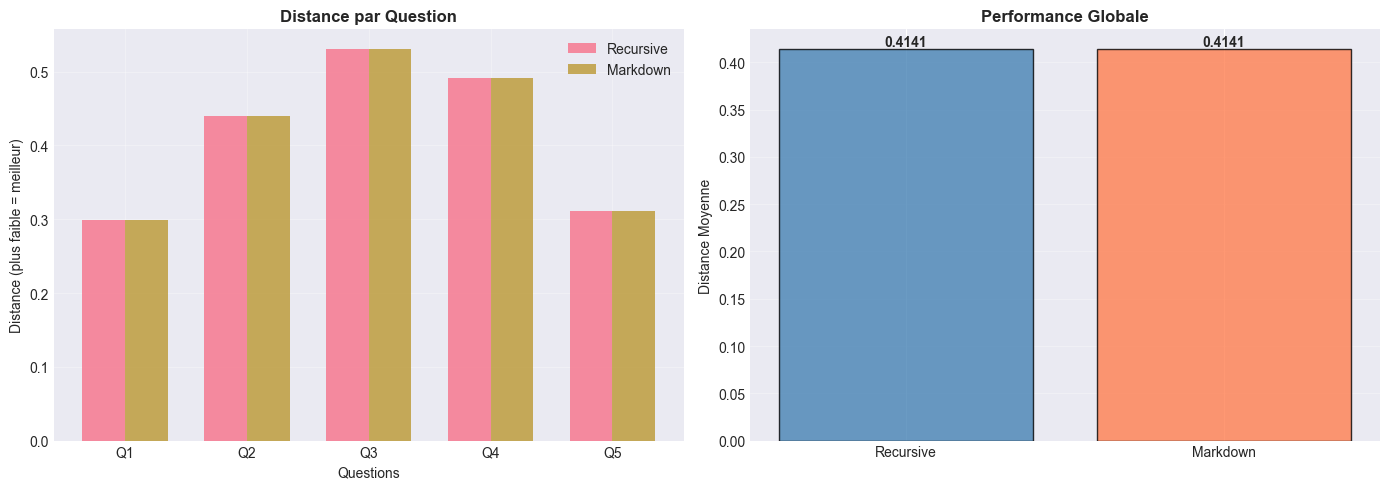

In [10]:
# Comparer les distances moyennes
avg_distance_recursive = np.mean([r['top1_distance'] for r in results_recursive])
avg_distance_markdown = np.mean([r['top1_distance'] for r in results_markdown])

print("\n=== COMPARAISON GLOBALE ===\n")
print(f"Distance moyenne (plus faible = meilleur) :")
print(f"  Recursive : {avg_distance_recursive:.4f}")
print(f"  Markdown  : {avg_distance_markdown:.4f}")

# Visualisation comparative
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: Distance par question
questions_short = [f"Q{i+1}" for i in range(len(test_queries))]
distances_recursive = [r['top1_distance'] for r in results_recursive]
distances_markdown = [r['top1_distance'] for r in results_markdown]

x = np.arange(len(questions_short))
width = 0.35

ax1.bar(x - width/2, distances_recursive, width, label='Recursive', alpha=0.8)
ax1.bar(x + width/2, distances_markdown, width, label='Markdown', alpha=0.8)
ax1.set_xlabel('Questions')
ax1.set_ylabel('Distance (plus faible = meilleur)')
ax1.set_title('Distance par Question', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(questions_short)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2: Comparaison moyenne
strategies = ['Recursive', 'Markdown']
avg_distances = [avg_distance_recursive, avg_distance_markdown]
colors = ['steelblue', 'coral']

bars = ax2.bar(strategies, avg_distances, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Distance Moyenne')
ax2.set_title('Performance Globale', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for bar, value in zip(bars, avg_distances):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.4f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()